Data Preparation

In [ ]:
import os

base_path = "/content/drive/MyDrive/Wildfire_Project"

folders = [
    "datasets",
    "notebooks",
    "models",
    "outputs"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created successfully!")


Folders created successfully!


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Wildfire_Project/datasets"

for file in ["Training.zip", "Test.zip", "Masks.zip"]:
    path = os.path.join(dataset_path, file)

    if os.path.exists(path):
        size_gb = os.path.getsize(path)/(1024**3)
        print(f"{file}: {size_gb:.2f} GB")

Training.zip: 1.18 GB
Test.zip: 0.28 GB
Masks.zip: 0.01 GB


In [ ]:
import zipfile
import os

dataset_path = "/content/drive/MyDrive/Wildfire_Project/datasets"

for file in ["Training.zip", "Test.zip", "Masks.zip"]:
    file_path = os.path.join(dataset_path, file)

    try:
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            print(f"✅ {file}")
            print(f"Files inside: {len(zip_ref.namelist())}")
            print("-"*40)

    except Exception as e:
        print(f"❌ {file}")
        print(e)

✅ Training.zip
Files inside: 39378
----------------------------------------
✅ Test.zip
Files inside: 8620
----------------------------------------
✅ Masks.zip
Files inside: 2004
----------------------------------------


In [ ]:
import os

train_fire = "/content/drive/MyDrive/Wildfire_Project/datasets/Training/Training/Fire"
train_nofire = "/content/drive/MyDrive/Wildfire_Project/datasets/Training/Training/No_Fire"

test_fire = "/content/drive/MyDrive/Wildfire_Project/datasets/Test/Test/Fire"
test_nofire = "/content/drive/MyDrive/Wildfire_Project/datasets/Test/Test/No_Fire"

masks = "/content/drive/MyDrive/Wildfire_Project/datasets/Masks/Masks"

print("Training Fire Images:", len(os.listdir(train_fire)))
print("Training No Fire Images:", len(os.listdir(train_nofire)))

print("Test Fire Images:", len(os.listdir(test_fire)))
print("Test No Fire Images:", len(os.listdir(test_nofire)))

print("Masks:", len(os.listdir(masks)))

Training Fire Images: 25018
Training No Fire Images: 14357
Test Fire Images: 5137
Test No Fire Images: 3480
Masks: 2003


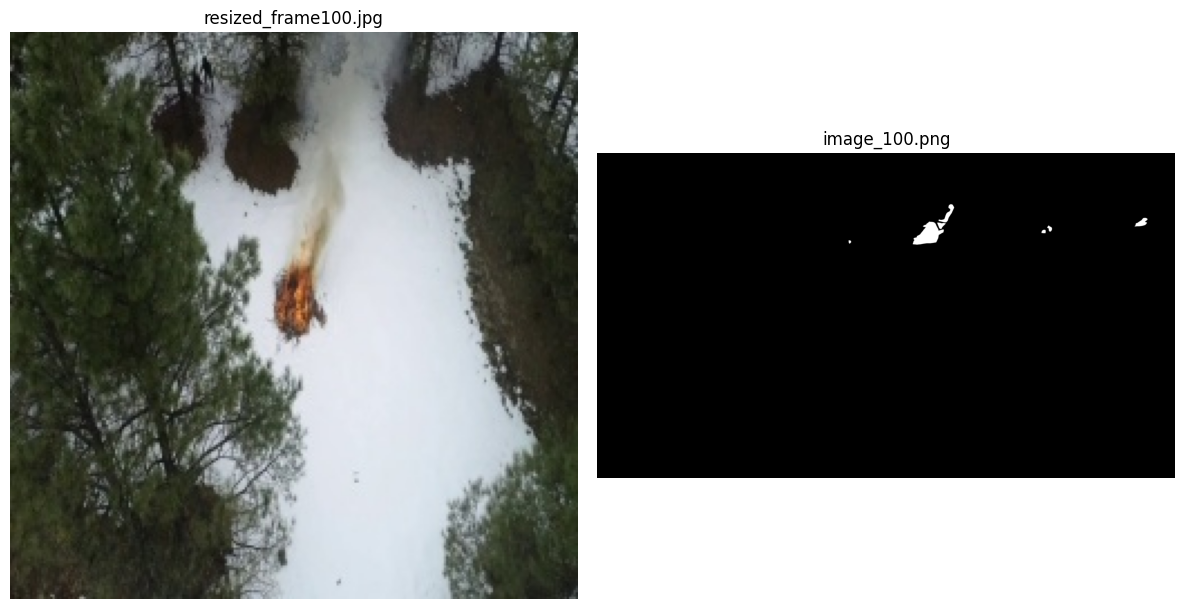

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

fire_path = "/content/drive/MyDrive/Wildfire_Project/datasets/Training/Training/Fire"
mask_path = "/content/drive/MyDrive/Wildfire_Project/datasets/Masks/Masks"

frame_num = 100

image_file = f"resized_frame{frame_num}.jpg"
mask_file = f"image_{frame_num}.png"

# Read image
image = cv2.imread(os.path.join(fire_path, image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Read mask
mask = cv2.imread(
    os.path.join(mask_path, mask_file),
    cv2.IMREAD_GRAYSCALE
)

# Display
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title(image_file)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title(mask_file)
plt.axis("off")

plt.tight_layout()
plt.show()

Data Preprocessing

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

fire_path = "/content/drive/MyDrive/Wildfire_Project/datasets/Training/Training/Fire"
mask_path = "/content/drive/MyDrive/Wildfire_Project/datasets/Masks/Masks"

image = cv2.imread(
    os.path.join(fire_path, "resized_frame100.jpg")
)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(
    os.path.join(mask_path, "image_100.png"),
    cv2.IMREAD_GRAYSCALE
)

# Resize mask to image size
mask = cv2.resize(
    mask,
    (254, 254),
    interpolation=cv2.INTER_NEAREST
)

# Normalize image
image = image.astype(np.float32) / 255.0

print("Image Shape :", image.shape)
print("Mask Shape  :", mask.shape)

print("Image Min :", image.min())
print("Image Max :", image.max())

print("Mask Unique Values :", np.unique(mask))

Image Shape : (254, 254, 3)
Mask Shape  : (254, 254)
Image Min : 0.011764706
Image Max : 0.9607843
Mask Unique Values : [0 1]


Data Loaders

In [3]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class FlameSegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.pairs = []

        for mask_file in os.listdir(mask_dir):

            num = mask_file.replace(
                "image_", ""
            ).replace(
                ".png",
                ""
            )

            image_file = f"resized_frame{num}.jpg"

            if os.path.exists(
                os.path.join(image_dir, image_file)
            ):
                self.pairs.append(
                    (image_file, mask_file)
                )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_file, mask_file = self.pairs[idx]

        image = cv2.imread(
            os.path.join(
                self.image_dir,
                image_file
            )
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = image.astype("float32") / 255.0

        mask = cv2.imread(
            os.path.join(
                self.mask_dir,
                mask_file
            ),
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.resize(
            mask,
            (254,254),
            interpolation=cv2.INTER_NEAREST
        )

        image = torch.tensor(
            image
        ).permute(2,0,1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [4]:
fire_path = "/content/drive/MyDrive/Wildfire_Project/datasets/Training/Training/Fire"
mask_path = "/content/drive/MyDrive/Wildfire_Project/datasets/Masks/Masks"

dataset = FlameSegmentationDataset(
    fire_path,
    mask_path
)

print("Dataset Size:", len(dataset))

image, mask = dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape :", mask.shape)

Dataset Size: 1997
Image Shape: torch.Size([3, 254, 254])
Mask Shape : torch.Size([1, 254, 254])


In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print("DataLoader Created Successfully!")

DataLoader Created Successfully!


U-Net Model

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2,
            output_padding=1
        )

        self.conv1 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        bn = self.bottleneck(p2)

        up1 = self.up1(bn)

        cat1 = torch.cat(
            [up1,d2],
            dim=1
        )

        c1 = self.conv1(cat1)

        up2 = self.up2(c1)

        cat2 = torch.cat(
            [up2,d1],
            dim=1
        )

        c2 = self.conv2(cat2)

        return self.final(c2)

In [7]:
model = UNet()
unet_model = model

In [8]:
optimizer = torch.optim.Adam(
    unet_model.parameters(),
    lr=0.001
)

print("Optimizer Created")

Optimizer Created


In [ ]:
num_epochs = 20

for epoch in range(start_epoch, num_epochs):

    model.train()

    running_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {avg_loss:.4f}"
    )

    # Save checkpoint every epoch
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }

    torch.save(
        checkpoint,
        "/content/drive/MyDrive/Wildfire_Project/models/unet_flame_checkpoint_latest.pth"
    )

Epoch 6/20 Loss: 1.6788
Epoch 7/20 Loss: 1.6168
Epoch 8/20 Loss: 1.5504
Epoch 9/20 Loss: 1.4777
Epoch 10/20 Loss: 1.4044
Epoch 11/20 Loss: 1.3240
Epoch 12/20 Loss: 1.2667
Epoch 13/20 Loss: 1.2118
Epoch 14/20 Loss: 1.1725
Epoch 15/20 Loss: 1.1245
Epoch 16/20 Loss: 1.0772
Epoch 17/20 Loss: 1.0189
Epoch 18/20 Loss: 0.9986
Epoch 19/20 Loss: 0.9387
Epoch 20/20 Loss: 0.8926


In [ ]:
num_epochs = 30

for epoch in range(start_epoch, num_epochs):

    model.train()

    running_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {avg_loss:.4f}"
    )

    # Save checkpoint every epoch
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }

    torch.save(
        checkpoint,
        "/content/drive/MyDrive/Wildfire_Project/models/unet_flame_checkpoint_latest.pth"
    )

Epoch 21/30 Loss: 0.8769
Epoch 22/30 Loss: 0.8535
Epoch 23/30 Loss: 0.8443
Epoch 24/30 Loss: 0.7917
Epoch 25/30 Loss: 0.7758
Epoch 26/30 Loss: 0.7525
Epoch 27/30 Loss: 0.7354
Epoch 28/30 Loss: 0.6991
Epoch 29/30 Loss: 0.6931
Epoch 30/30 Loss: 0.6745


In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    "/content/drive/MyDrive/Wildfire_Project/models/unet_flame_checkpoint_latest.pth",
    map_location=device
)

unet_model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]

print("Loaded Epoch:", start_epoch)

Loaded Epoch: 30


Attention U-Net Model

In [11]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

      g1 = self.W_g(g)
      x1 = self.W_x(x)

      if g1.shape[2:] != x1.shape[2:]:
          g1 = F.interpolate(
              g1,
              size=x1.shape[2:],
              mode='bilinear',
              align_corners=False
          )

      psi = self.relu(g1 + x1)
      psi = self.psi(psi)

      return x * psi

In [12]:
class AttentionUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2,
            output_padding=1
        )

        self.att1 = AttentionBlock(
            F_g=128,
            F_l=128,
            F_int=64
        )

        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.att2 = AttentionBlock(
            F_g=64,
            F_l=64,
            F_int=32
        )

        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self,x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        bn = self.bottleneck(p2)

        up1 = self.up1(bn)

        d2_att = self.att1(up1,d2)

        up1 = F.interpolate(
            up1,
            size=d2_att.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        cat1 = torch.cat([up1,d2_att], dim=1)

        c1 = self.conv1(cat1)

        up2 = self.up2(c1)

        d1_att = self.att2(up2,d1)

        up2 = F.interpolate(
            up2,
            size=d1_att.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        cat2 = torch.cat([up2,d1_att], dim=1)

        c2 = self.conv2(cat2)

        return self.final(c2)

In [13]:
attention_model = AttentionUNet().to(device)

x = torch.randn(1,3,256,256).to(device)

y = attention_model(x)

print(y.shape)

torch.Size([1, 1, 256, 256])


In [14]:
optimizer = torch.optim.Adam(
    attention_model.parameters(),
    lr=0.001
)

print("Optimizer Created")

Optimizer Created


In [ ]:
num_epochs = 30

best_loss = float("inf")

for epoch in range(0, num_epochs):

    # -------------------
    # TRAINING PHASE
    # -------------------
    model.train()

    running_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # -------------------
    # VALIDATION PHASE (IMPORTANT)
    # -------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # -------------------
    # PRINT METRICS
    # -------------------
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # -------------------
    # SAVE BEST MODEL ONLY
    # -------------------
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": avg_val_loss
        }

        torch.save(
            checkpoint,
            "/content/drive/MyDrive/Wildfire_Project/models/best_attention_unet.pth"
        )

        print("✅ Best model saved")

Epoch 1/30 | Train Loss: 1.6780 | Val Loss: 1.6828
✅ Best model saved
Epoch 2/30 | Train Loss: 1.6603 | Val Loss: 1.6512
✅ Best model saved
Epoch 3/30 | Train Loss: 1.6427 | Val Loss: 1.6253
✅ Best model saved
Epoch 4/30 | Train Loss: 1.6329 | Val Loss: 1.6553
Epoch 5/30 | Train Loss: 1.6184 | Val Loss: 1.6141
✅ Best model saved
Epoch 6/30 | Train Loss: 1.5986 | Val Loss: 1.6919
Epoch 7/30 | Train Loss: 1.5942 | Val Loss: 1.6737
Epoch 8/30 | Train Loss: 1.5653 | Val Loss: 1.5588
✅ Best model saved
Epoch 9/30 | Train Loss: 1.5204 | Val Loss: 1.5206
✅ Best model saved
Epoch 10/30 | Train Loss: 1.4873 | Val Loss: 1.4630
✅ Best model saved
Epoch 11/30 | Train Loss: 1.4397 | Val Loss: 1.4403
✅ Best model saved
Epoch 12/30 | Train Loss: 1.3935 | Val Loss: 1.4107
✅ Best model saved
Epoch 13/30 | Train Loss: 1.3591 | Val Loss: 1.3110
✅ Best model saved
Epoch 14/30 | Train Loss: 1.3010 | Val Loss: 1.3434
Epoch 15/30 | Train Loss: 1.2444 | Val Loss: 1.2135
✅ Best model saved
Epoch 16/30 | Train 

In [15]:
checkpoint = torch.load(
    "/content/drive/MyDrive/Wildfire_Project/models/best_attention_unet.pth",
    map_location=device
)

attention_model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]

print("Loaded Epoch:", start_epoch)

Loaded Epoch: 30


DeepLabV3+ Model

In [16]:
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = deeplabv3_resnet50(weights="DEFAULT")

model.classifier[4] = nn.Conv2d(
    256,
    1,
    kernel_size=1
)

deeplab_model = model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:03<00:00, 45.5MB/s]


In [17]:
deeplab_model.eval()

x = torch.randn(1,3,254,254).to(device)

with torch.no_grad():
    y = model(x)["out"]

print(y.shape)

torch.Size([1, 1, 254, 254])


In [18]:
optimizer = torch.optim.Adam(
    deeplab_model.parameters(),
    lr=0.001
)

print("Optimizer Created")

Optimizer Created


In [ ]:
num_epochs = 30

best_loss = float("inf")

for epoch in range(start_epoch, num_epochs):

    # -------------------
    # TRAINING PHASE
    # -------------------
    model.train()

    running_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)["out"]

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # -------------------
    # VALIDATION PHASE (IMPORTANT)
    # -------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)["out"]
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # -------------------
    # PRINT METRICS
    # -------------------
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # -------------------
    # SAVE BEST MODEL ONLY
    # -------------------
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": avg_val_loss
        }

        torch.save(
            checkpoint,
            "/content/drive/MyDrive/Wildfire_Project/models/deeplabv3.pth"
        )

        print("✅ Best model saved")

Epoch 5/30 | Train Loss: 0.6454 | Val Loss: 0.6829
✅ Best model saved
Epoch 6/30 | Train Loss: 0.5881 | Val Loss: 0.5727
✅ Best model saved
Epoch 7/30 | Train Loss: 0.5400 | Val Loss: 0.5480
✅ Best model saved
Epoch 8/30 | Train Loss: 0.5128 | Val Loss: 0.5271
✅ Best model saved
Epoch 9/30 | Train Loss: 0.4860 | Val Loss: 0.4976
✅ Best model saved
Epoch 10/30 | Train Loss: 0.4778 | Val Loss: 0.4977
Epoch 11/30 | Train Loss: 0.4514 | Val Loss: 0.4622
✅ Best model saved
Epoch 12/30 | Train Loss: 0.4386 | Val Loss: 0.5324
Epoch 13/30 | Train Loss: 0.4311 | Val Loss: 0.4602
✅ Best model saved
Epoch 14/30 | Train Loss: 0.4351 | Val Loss: 0.5297
Epoch 15/30 | Train Loss: 0.4265 | Val Loss: 0.4477
✅ Best model saved
Epoch 16/30 | Train Loss: 0.4010 | Val Loss: 0.4272
✅ Best model saved


In [19]:
checkpoint = torch.load(
    "/content/drive/MyDrive/Wildfire_Project/models/deeplabv3.pth",
    map_location=device
)

deeplab_model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]

print("Loaded Epoch:", start_epoch)

Loaded Epoch: 16


Evaluation Metrics

In [20]:
criterion = torch.nn.BCEWithLogitsLoss()

print("Loss Function Created")

Loss Function Created


In [21]:
def combined_loss(preds, targets):

    bce = bce_loss(preds, targets)

    dice = dice_loss(preds, targets)

    return bce + dice

In [22]:
import torch

def dice_score(preds, targets):

    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        preds.sum() +
        targets.sum() +
        1e-6
    )

    return dice.item()

In [23]:
def iou_score(preds, targets):

    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    union = (
        preds.sum() +
        targets.sum() -
        intersection
    )

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return iou.item()

In [24]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

print("Train Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))

Train Samples: 1597
Validation Samples: 400


Model Comparison

In [27]:
# =====================================================
# U-NET EVALUATION
# =====================================================

unet_model.eval()
unet_model = unet_model.to(device)

total_dice = 0
total_iou = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = unet_model(images)

        total_dice += dice_score(
            outputs,
            masks
        )

        total_iou += iou_score(
            outputs,
            masks
        )

avg_dice_unet = total_dice / len(val_loader)
avg_iou_unet = total_iou / len(val_loader)


# =====================================================
# ATTENTION U-NET EVALUATION
# =====================================================

attention_model.eval()

total_dice = 0
total_iou = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = attention_model(images)

        total_dice += dice_score(
            outputs,
            masks
        )

        total_iou += iou_score(
            outputs,
            masks
        )

avg_dice_att = total_dice / len(val_loader)
avg_iou_att = total_iou / len(val_loader)


# =====================================================
# DEEPLABV3+ EVALUATION
# =====================================================

deeplab_model.eval()

total_dice = 0
total_iou = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = deeplab_model(images)["out"]

        total_dice += dice_score(
            outputs,
            masks
        )

        total_iou += iou_score(
            outputs,
            masks
        )

avg_dice_deeplab = total_dice / len(val_loader)
avg_iou_deeplab = total_iou / len(val_loader)


# =====================================================
# RESULTS
# =====================================================

print("\nMODEL COMPARISON")
print("-" * 50)

print(
    f"U-Net           Dice: {avg_dice_unet:.4f} | IoU: {avg_iou_unet:.4f}"
)

print(
    f"Attention U-Net Dice: {avg_dice_att:.4f} | IoU: {avg_iou_att:.4f}"
)

print(
    f"DeepLabV3+      Dice: {avg_dice_deeplab:.4f} | IoU: {avg_iou_deeplab:.4f}"
)

print("\nBEST MODEL")
print("-" * 50)

best_dice = max(
    avg_dice_unet,
    avg_dice_att,
    avg_dice_deeplab
)

best_iou = max(
    avg_iou_unet,
    avg_iou_att,
    avg_iou_deeplab
)

if best_dice == avg_dice_unet:
    print("✓ Highest Dice Score : U-Net")
elif best_dice == avg_dice_att:
    print("✓ Highest Dice Score : Attention U-Net")
else:
    print("✓ Highest Dice Score : DeepLabV3+")

if best_iou == avg_iou_unet:
    print("✓ Highest IoU Score  : U-Net")
elif best_iou == avg_iou_att:
    print("✓ Highest IoU Score  : Attention U-Net")
else:
    print("✓ Highest IoU Score  : DeepLabV3+")


MODEL COMPARISON
--------------------------------------------------
U-Net           Dice: 0.6500 | IoU: 0.4830
Attention U-Net Dice: 0.6287 | IoU: 0.4603
DeepLabV3+      Dice: 0.7332 | IoU: 0.5810

BEST MODEL
--------------------------------------------------
✓ Highest Dice Score : DeepLabV3+
✓ Highest IoU Score  : DeepLabV3+


Prediction Results and Fire Severity Assessment

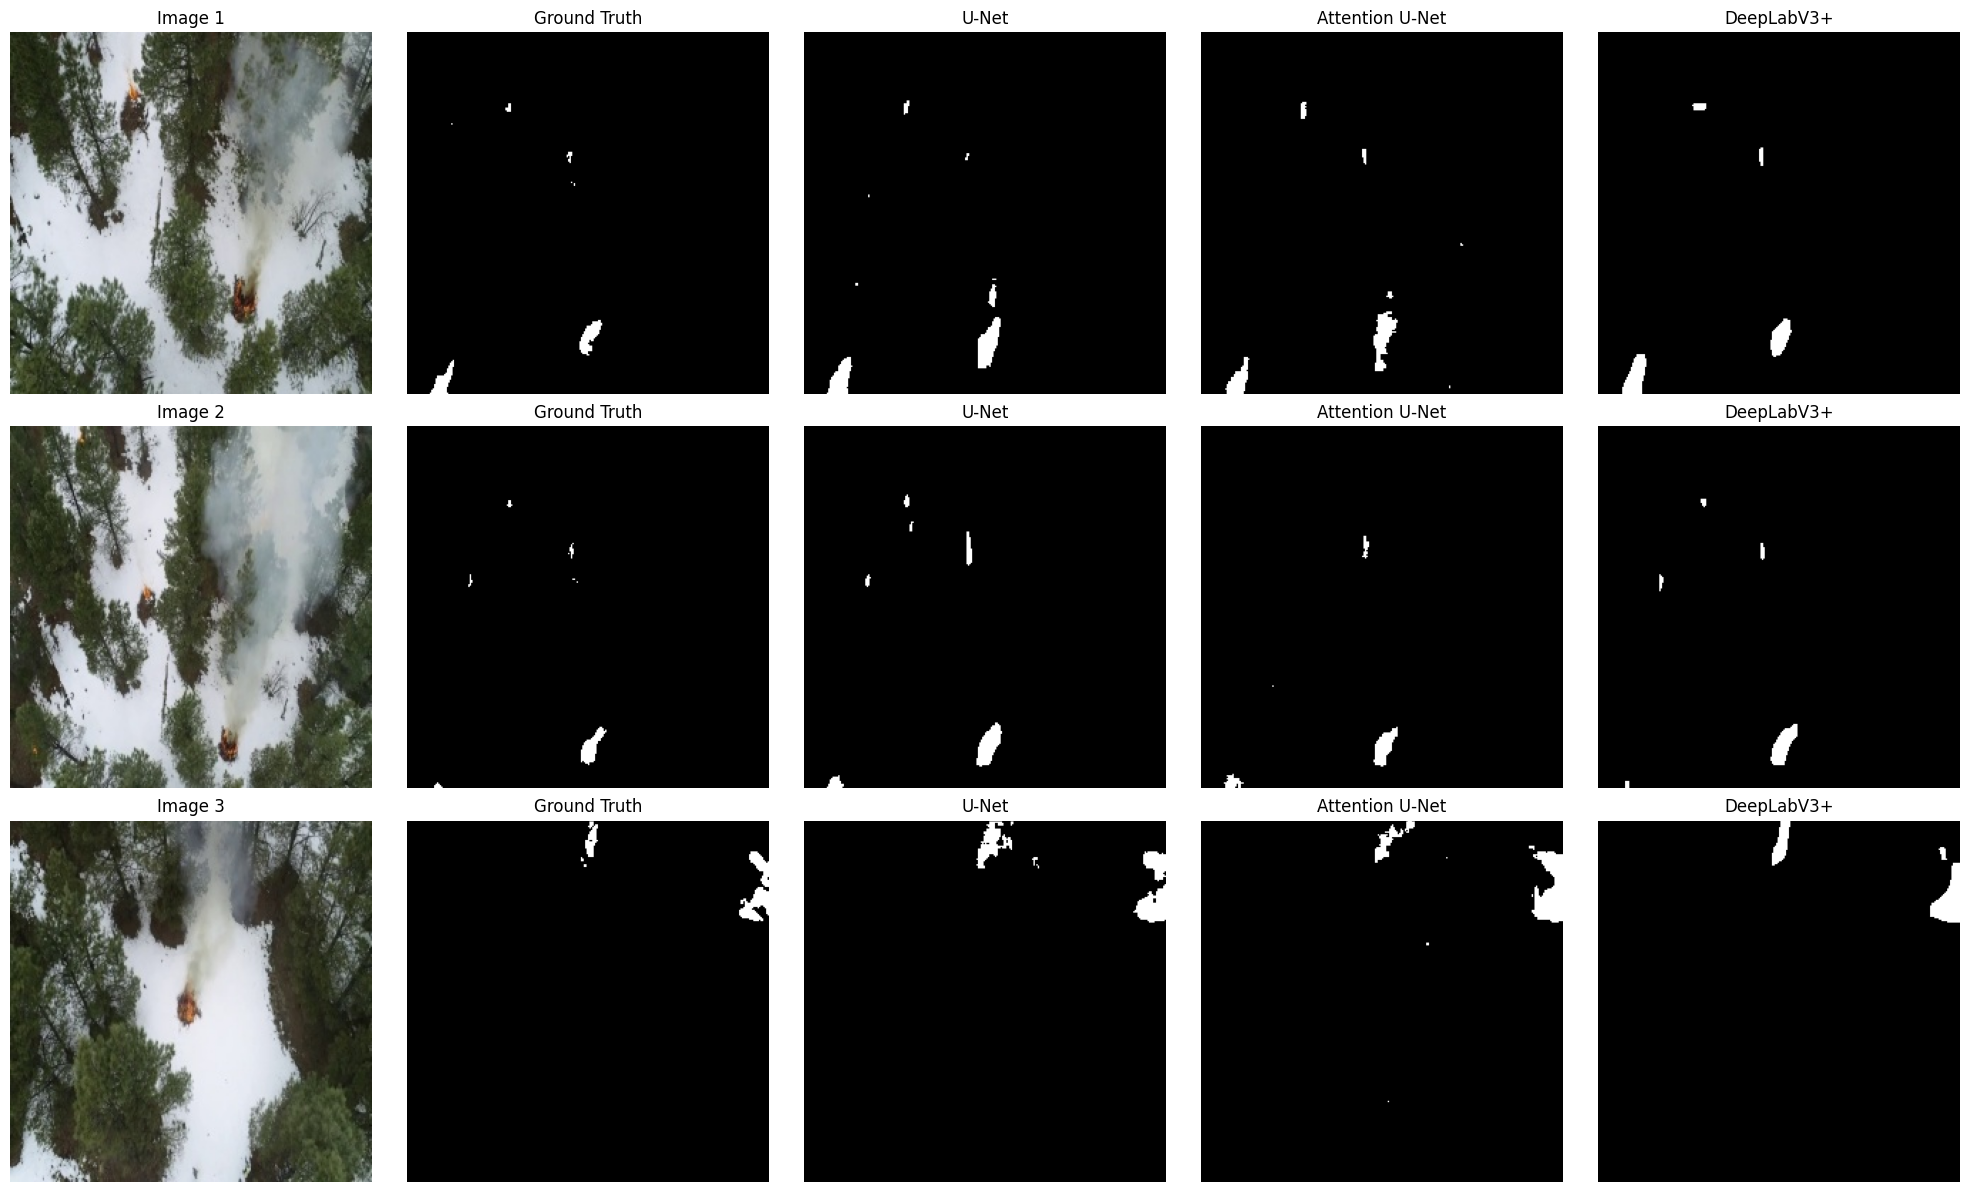



IMAGE 1
------------------------------------------------------------

U-NET
Prediction Min : 2.6522226e-17
Prediction Max : 0.999969
Prediction Mean: 0.012778069
Fire Pixels Predicted: 738.0
Ground Truth Fire Pixels: 412.0
Fire Percentage: 1.1439022878045757
Risk Level: Moderate Risk

ATTENTION U-NET
Prediction Min : 1.0148812e-13
Prediction Max : 0.999894
Prediction Mean: 0.011865759
Fire Pixels Predicted: 685.0
Ground Truth Fire Pixels: 412.0
Fire Percentage: 1.0617521235042469
Risk Level: Moderate Risk

DEEPLABV3+
Prediction Min : 0.0
Prediction Max : 0.99999964
Prediction Mean: 0.010185857
Fire Pixels Predicted: 644.0
Ground Truth Fire Pixels: 412.0
Fire Percentage: 0.9982019964039928
Risk Level: Low Risk

IMAGE 2
------------------------------------------------------------

U-NET
Prediction Min : 7.719982e-22
Prediction Max : 0.9999999
Prediction Mean: 0.009427926
Fire Pixels Predicted: 525.0
Ground Truth Fire Pixels: 277.0
Fire Percentage: 0.813751627503255
Risk Level: Low Risk

In [28]:
import matplotlib.pyplot as plt
import torch
import random

# -----------------------------
# Evaluation Mode
# -----------------------------
unet_model.eval()
attention_model.eval()
deeplab_model.eval()

num_images = 3

# -----------------------------
# Get Batch
# -----------------------------
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

# -----------------------------
# Predictions
# -----------------------------
with torch.no_grad():

    unet_preds = torch.sigmoid(
        unet_model(images)
    )

    att_preds = torch.sigmoid(
        attention_model(images)
    )

    deeplab_preds = torch.sigmoid(
        deeplab_model(images)["out"]
    )

# -----------------------------
# Random Images
# -----------------------------
indices = random.sample(
    range(images.shape[0]),
    num_images
)

# -----------------------------
# Plot Predictions
# -----------------------------
plt.figure(figsize=(20,12))

for row, idx in enumerate(indices):

    image = images[idx].permute(1,2,0).cpu().numpy()

    mask = masks[idx].squeeze().cpu().numpy()

    unet_pred = unet_preds[idx].squeeze().cpu().numpy()
    att_pred = att_preds[idx].squeeze().cpu().numpy()
    deeplab_pred = deeplab_preds[idx].squeeze().cpu().numpy()

    unet_binary = (
        unet_pred > 0.5
    ).astype(float)

    att_binary = (
        att_pred > 0.5
    ).astype(float)

    deeplab_binary = (
        deeplab_pred > 0.5
    ).astype(float)

    # -----------------------------
    # Input Image
    # -----------------------------
    plt.subplot(num_images,5,row*5+1)

    plt.imshow(image)
    plt.title(f"Image {row+1}")
    plt.axis("off")

    # -----------------------------
    # Ground Truth
    # -----------------------------
    plt.subplot(num_images,5,row*5+2)

    plt.imshow(mask,cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # -----------------------------
    # U-Net
    # -----------------------------
    plt.subplot(num_images,5,row*5+3)

    plt.imshow(
        unet_binary,
        cmap="gray"
    )

    plt.title("U-Net")
    plt.axis("off")

    # -----------------------------
    # Attention U-Net
    # -----------------------------
    plt.subplot(num_images,5,row*5+4)

    plt.imshow(
        att_binary,
        cmap="gray"
    )

    plt.title("Attention U-Net")
    plt.axis("off")

    # -----------------------------
    # DeepLabV3+
    # -----------------------------
    plt.subplot(num_images,5,row*5+5)

    plt.imshow(
        deeplab_binary,
        cmap="gray"
    )

    plt.title("DeepLabV3+")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# Fire Severity Comparison
# ==========================================================

print("\n" + "="*100)

for row, idx in enumerate(indices):

    mask = masks[idx].squeeze().cpu().numpy()

    unet_pred = unet_preds[idx].squeeze().cpu().numpy()
    att_pred = att_preds[idx].squeeze().cpu().numpy()
    deeplab_pred = deeplab_preds[idx].squeeze().cpu().numpy()

    unet_binary = (
        unet_pred > 0.5
    ).astype(float)

    att_binary = (
        att_pred > 0.5
    ).astype(float)

    deeplab_binary = (
        deeplab_pred > 0.5
    ).astype(float)

    total_pixels = unet_binary.size
    gt_pixels = mask.sum()

    # =====================================================
    # U-Net
    # =====================================================

    unet_pixels = unet_binary.sum()

    unet_percentage = (
        unet_pixels /
        total_pixels
    ) * 100

    if unet_percentage < 1:
        unet_risk = "Low Risk"
    elif unet_percentage < 5:
        unet_risk = "Moderate Risk"
    else:
        unet_risk = "High Risk"

    # =====================================================
    # Attention U-Net
    # =====================================================

    att_pixels = att_binary.sum()

    att_percentage = (
        att_pixels /
        total_pixels
    ) * 100

    if att_percentage < 1:
        att_risk = "Low Risk"
    elif att_percentage < 5:
        att_risk = "Moderate Risk"
    else:
        att_risk = "High Risk"

    # =====================================================
    # DeepLabV3+
    # =====================================================

    deeplab_pixels = deeplab_binary.sum()

    deeplab_percentage = (
        deeplab_pixels /
        total_pixels
    ) * 100

    if deeplab_percentage < 1:
        deeplab_risk = "Low Risk"
    elif deeplab_percentage < 5:
        deeplab_risk = "Moderate Risk"
    else:
        deeplab_risk = "High Risk"

    # =====================================================
    # Results
    # =====================================================

    print(f"\nIMAGE {row+1}")
    print("-"*60)

    print("\nU-NET")
    print("Prediction Min :", unet_pred.min())
    print("Prediction Max :", unet_pred.max())
    print("Prediction Mean:", unet_pred.mean())
    print("Fire Pixels Predicted:", unet_pixels)
    print("Ground Truth Fire Pixels:", gt_pixels)
    print("Fire Percentage:", unet_percentage)
    print("Risk Level:", unet_risk)

    print("\nATTENTION U-NET")
    print("Prediction Min :", att_pred.min())
    print("Prediction Max :", att_pred.max())
    print("Prediction Mean:", att_pred.mean())
    print("Fire Pixels Predicted:", att_pixels)
    print("Ground Truth Fire Pixels:", gt_pixels)
    print("Fire Percentage:", att_percentage)
    print("Risk Level:", att_risk)

    print("\nDEEPLABV3+")
    print("Prediction Min :", deeplab_pred.min())
    print("Prediction Max :", deeplab_pred.max())
    print("Prediction Mean:", deeplab_pred.mean())
    print("Fire Pixels Predicted:", deeplab_pixels)
    print("Ground Truth Fire Pixels:", gt_pixels)
    print("Fire Percentage:", deeplab_percentage)
    print("Risk Level:", deeplab_risk)

    print("="*100)